Requested Plots to Make:

1. Plot inbound and outbound path traces
    i. Asked to see outbound and inbound path traces
    ii. Asked to look at supposed two different strategirs for searching (inbound paths I believe)
    - Should be done for:
        - individual animals
        - multiple animals
        - different sessions

    My interpretation:
        i. For each mouse, plot outbound paths in one column, inbound paths in next column. Each row should be one session (or day, should use columns of dataframe/dataarray to set this as input parameter to function, ordered from earliest to latest). Trials should use a colourmap, normalised so that it covers 0.2 to 1.0, with earlier trials for each session being lighter. 
        ii. Second plot should be like the first, but without outbound paths. Should have input parameter like `groups = {'g1': {'mouse1', 'mouse2'}, 'g2': {'mouse3'}}`.

        Both plots should use `movement` python package functions to plot these path traces using DLC pose data. Should take centroid of datapoints passed as input list to function, i.e. `centroid_points = {'nose', 'torso', 'rightarm', 'rightleg'}`, but by default should just be all the pose points in the DLC data (read the data and actually hardcode this). this is more in case it needs to change. 
        Both plots should also overlay a static frame at the start, perhaps the first frame of the video recording. 
        Both plots should have fixed axes so that the entire space is visible. 

## Implementation: `plot_path_grid`

One function (`data_conduit.qc.plot_path_grid`) draws both figures. Rows and columns are each any trials-table column (`session`, `day`, `group`, `mouseID`) or the special `'segment'` (the outbound|inbound pair). Grouping just adds a `group` column via `groups={...}`, so it's another axis you can toggle onto rows or columns.

- Colouring defaults to per mouse, but grouped calls switch to per group unless you pass `color_by='mouseID'`; trials ramp **0.2 → 1.0** in trial order (earlier lighter).
- Per-session first `.avi` frame as a static background; fixed pixel axes.
- Centroid over `centroid_points`, default all keypoints: `('nose', 'lear', 'rear', 'body', 'tailbase')`.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pathlib, data_conduit
from data_conduit.qc import qc_datastructure, plot_path_grid

# Anchor to the repo root so ROOT resolves regardless of the notebook's working dir.
REPO = pathlib.Path(data_conduit.__file__).resolve().parents[2]
ROOT = REPO / 'datasets/firstdata/BonsaiFiles'

ds = qc_datastructure(ROOT, depth=2, level_names=('mouseID', 'day'),
                      streams=('dlc',), l1_selector='Day 11')
result = ds.load()

# Keep only trial rows from sessions that are actually present in the DLC pose stream.
# The full result may include trial-only sessions because trials and DLC are loaded as
# separate streams.
dlc_sessions = set(result['dlc:position'].coords['session'].values)
filtered_results = result.copy()
filtered_results['trials'] = result['trials'][
    result['trials']['session'].isin(dlc_sessions)
].copy()

sorted(set(result['trials']['mouseID']))


                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  

                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  


['FLR_M01569521', 'FL_M01569519', 'FbR_M01569522', 'MR_M01569515']

In [2]:
print(f'Result keys: {result.keys()}')

display(result['trials'])
display(result['dlc:position'].to_dataframe())

print(f'Number of sessions: {result["trials"]["session"].nunique()}')
print(f'Number of sessions with DLC: {filtered_results["trials"]["session"].nunique()}')

display(filtered_results['trials'])

Result keys: dict_keys(['trials', 'dlc:position', 'dlc:confidence'])


,trial_index,start_time,end_time,tz_triggered_time,outbound_start_time,outbound_end_time,inbound_start_time,inbound_end_time,TTT,TTP,ChosenPort,CorrectPort,outcome,LED,angle_offset,target_zone_size,session,mouseID,day
0,1,14111.769984,14139.740992,14125.364992,14111.769984,14125.364992,14125.364992,14139.740992,13.595008,14.376000,16,16,Success,ON,0.0,200.0,2026-04-08T15-43-23,FLR_M01569521,Day 11
1,2,14139.740992,14166.088480,14164.786976,14139.740992,14164.786976,14164.786976,14166.088480,25.045984,1.301504,16,16,Success,ON,0.0,200.0,2026-04-08T15-43-23,FLR_M01569521,Day 11
2,3,14166.088480,14177.381984,14174.778976,14166.088480,14174.778976,14174.778976,14177.381984,8.690496,2.603008,16,16,Success,ON,0.0,200.0,2026-04-08T15-43-23,FLR_M01569521,Day 11
3,4,14177.381984,14190.016992,14187.512000,14177.381984,14187.512000,14187.512000,14190.016992,10.130016,2.504992,16,16,Success,ON,0.0,200.0,2026-04-08T15-43-23,FLR_M01569521,Day 11
4,5,14190.016992,14204.030976,14200.828992,14190.016992,14200.828992,14200.828992,14204.030976,10.812000,3.201984,16,16,Success,ON,0.0,200.0,2026-04-08T15-43-23,FLR_M01569521,Day 11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
579,12,7752.445504,7786.061984,7771.034976,7752.445504,7771.034976,7771.034976,7786.061984,18.589472,15.027008,-1,1,Miss,OFF,NaN,180.0,2026-04-08T13-53-18,MR_M01569515,Day 11
580,13,7786.061984,7803.125984,7788.117984,7786.061984,7788.117984,7788.117984,7803.125984,2.056000,15.008000,-1,1,Miss,OFF,NaN,180.0,2026-04-08T13-53-18,MR_M01569515,Day 11
581,14,7803.125984,7821.994976,7819.616000,7803.125984,7819.616000,7819.616000,7821.994976,16.490016,2.378976,7,1,Failure,OFF,NaN,180.0,2026-04-08T13-53-18,MR_M01569515,Day 11
582,15,7821.994976,7839.059488,7824.052000,7821.994976,7824.052000,7824.052000,7839.059488,2.057024,15.007488,-1,1,Miss,OFF,120.0,180.0,2026-04-08T13-53-18,MR_M01569515,Day 11


session        mouseID     day  \
Time         keypoints space                                               
15994.716576 nose      x      2026-04-08T16-14-45  FLR_M01569521  Day 11   
                       y      2026-04-08T16-14-45  FLR_M01569521  Day 11   
             lear      x      2026-04-08T16-14-45  FLR_M01569521  Day 11   
                       y      2026-04-08T16-14-45  FLR_M01569521  Day 11   
             rear      x      2026-04-08T16-14-45  FLR_M01569521  Day 11   
...                                           ...            ...     ...   
7863.979104  rear      y      2026-04-08T13-53-18   MR_M01569515  Day 11   
             body      x      2026-04-08T13-53-18   MR_M01569515  Day 11   
                       y      2026-04-08T13-53-18   MR_M01569515  Day 11   
             tailbase  x      2026-04-08T13-53-18   MR_M01569515  Day 11   
                       y      2026-04-08T13-53-18   MR_M01569515  Day 11   

                                position  
Time         keypoints space              
15994.716576 nose      x      555.145940  
                       y       87.111534  
             lear      x      548.847800  
                       y       94.448814  
             rear      x      556.936500  
...                                  ...  
7863.979104  rear      y      365.457700  
             body      x      526.696170  
                       y      377.318100  
             tailbase  x      542.634900  
                       y      385.521300  

[1899150 rows x 4 columns]

Number of sessions: 23
Number of sessions with DLC: 11


,trial_index,start_time,end_time,tz_triggered_time,outbound_start_time,outbound_end_time,inbound_start_time,inbound_end_time,TTT,TTP,ChosenPort,CorrectPort,outcome,LED,angle_offset,target_zone_size,session,mouseID,day
106,1,15995.274976,16008.442976,16006.769984,15995.274976,16006.769984,16006.769984,16008.442976,11.495008,1.672992,16,16,Success,ON,0.0,190.0,2026-04-08T16-14-45,FLR_M01569521,Day 11
107,2,16008.442976,16030.800000,16020.786976,16008.442976,16020.786976,16020.786976,16030.800000,12.344000,10.013024,-1,16,Miss,OFF,0.0,190.0,2026-04-08T16-14-45,FLR_M01569521,Day 11
108,3,16030.800000,16048.220992,16038.204000,16030.800000,16038.204000,16038.204000,16048.220992,7.404000,10.016992,-1,16,Miss,OFF,NaN,190.0,2026-04-08T16-14-45,FLR_M01569521,Day 11
109,4,16048.220992,16067.304992,16058.117984,16048.220992,16058.117984,16058.117984,16067.304992,9.896992,9.187008,16,16,Success,OFF,NaN,190.0,2026-04-08T16-14-45,FLR_M01569521,Day 11
110,5,16067.304992,16086.676992,16076.665984,16067.304992,16076.665984,16076.665984,16086.676992,9.360992,10.011008,-1,16,Miss,OFF,0.0,190.0,2026-04-08T16-14-45,FLR_M01569521,Day 11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
579,12,7752.445504,7786.061984,7771.034976,7752.445504,7771.034976,7771.034976,7786.061984,18.589472,15.027008,-1,1,Miss,OFF,NaN,180.0,2026-04-08T13-53-18,MR_M01569515,Day 11
580,13,7786.061984,7803.125984,7788.117984,7786.061984,7788.117984,7788.117984,7803.125984,2.056000,15.008000,-1,1,Miss,OFF,NaN,180.0,2026-04-08T13-53-18,MR_M01569515,Day 11
581,14,7803.125984,7821.994976,7819.616000,7803.125984,7819.616000,7819.616000,7821.994976,16.490016,2.378976,7,1,Failure,OFF,NaN,180.0,2026-04-08T13-53-18,MR_M01569515,Day 11
582,15,7821.994976,7839.059488,7824.052000,7821.994976,7824.052000,7824.052000,7839.059488,2.057024,15.007488,-1,1,Miss,OFF,120.0,180.0,2026-04-08T13-53-18,MR_M01569515,Day 11


### Plot 1 — outbound vs inbound, per mouse

Rows = sessions (earliest → latest), columns = outbound | inbound.

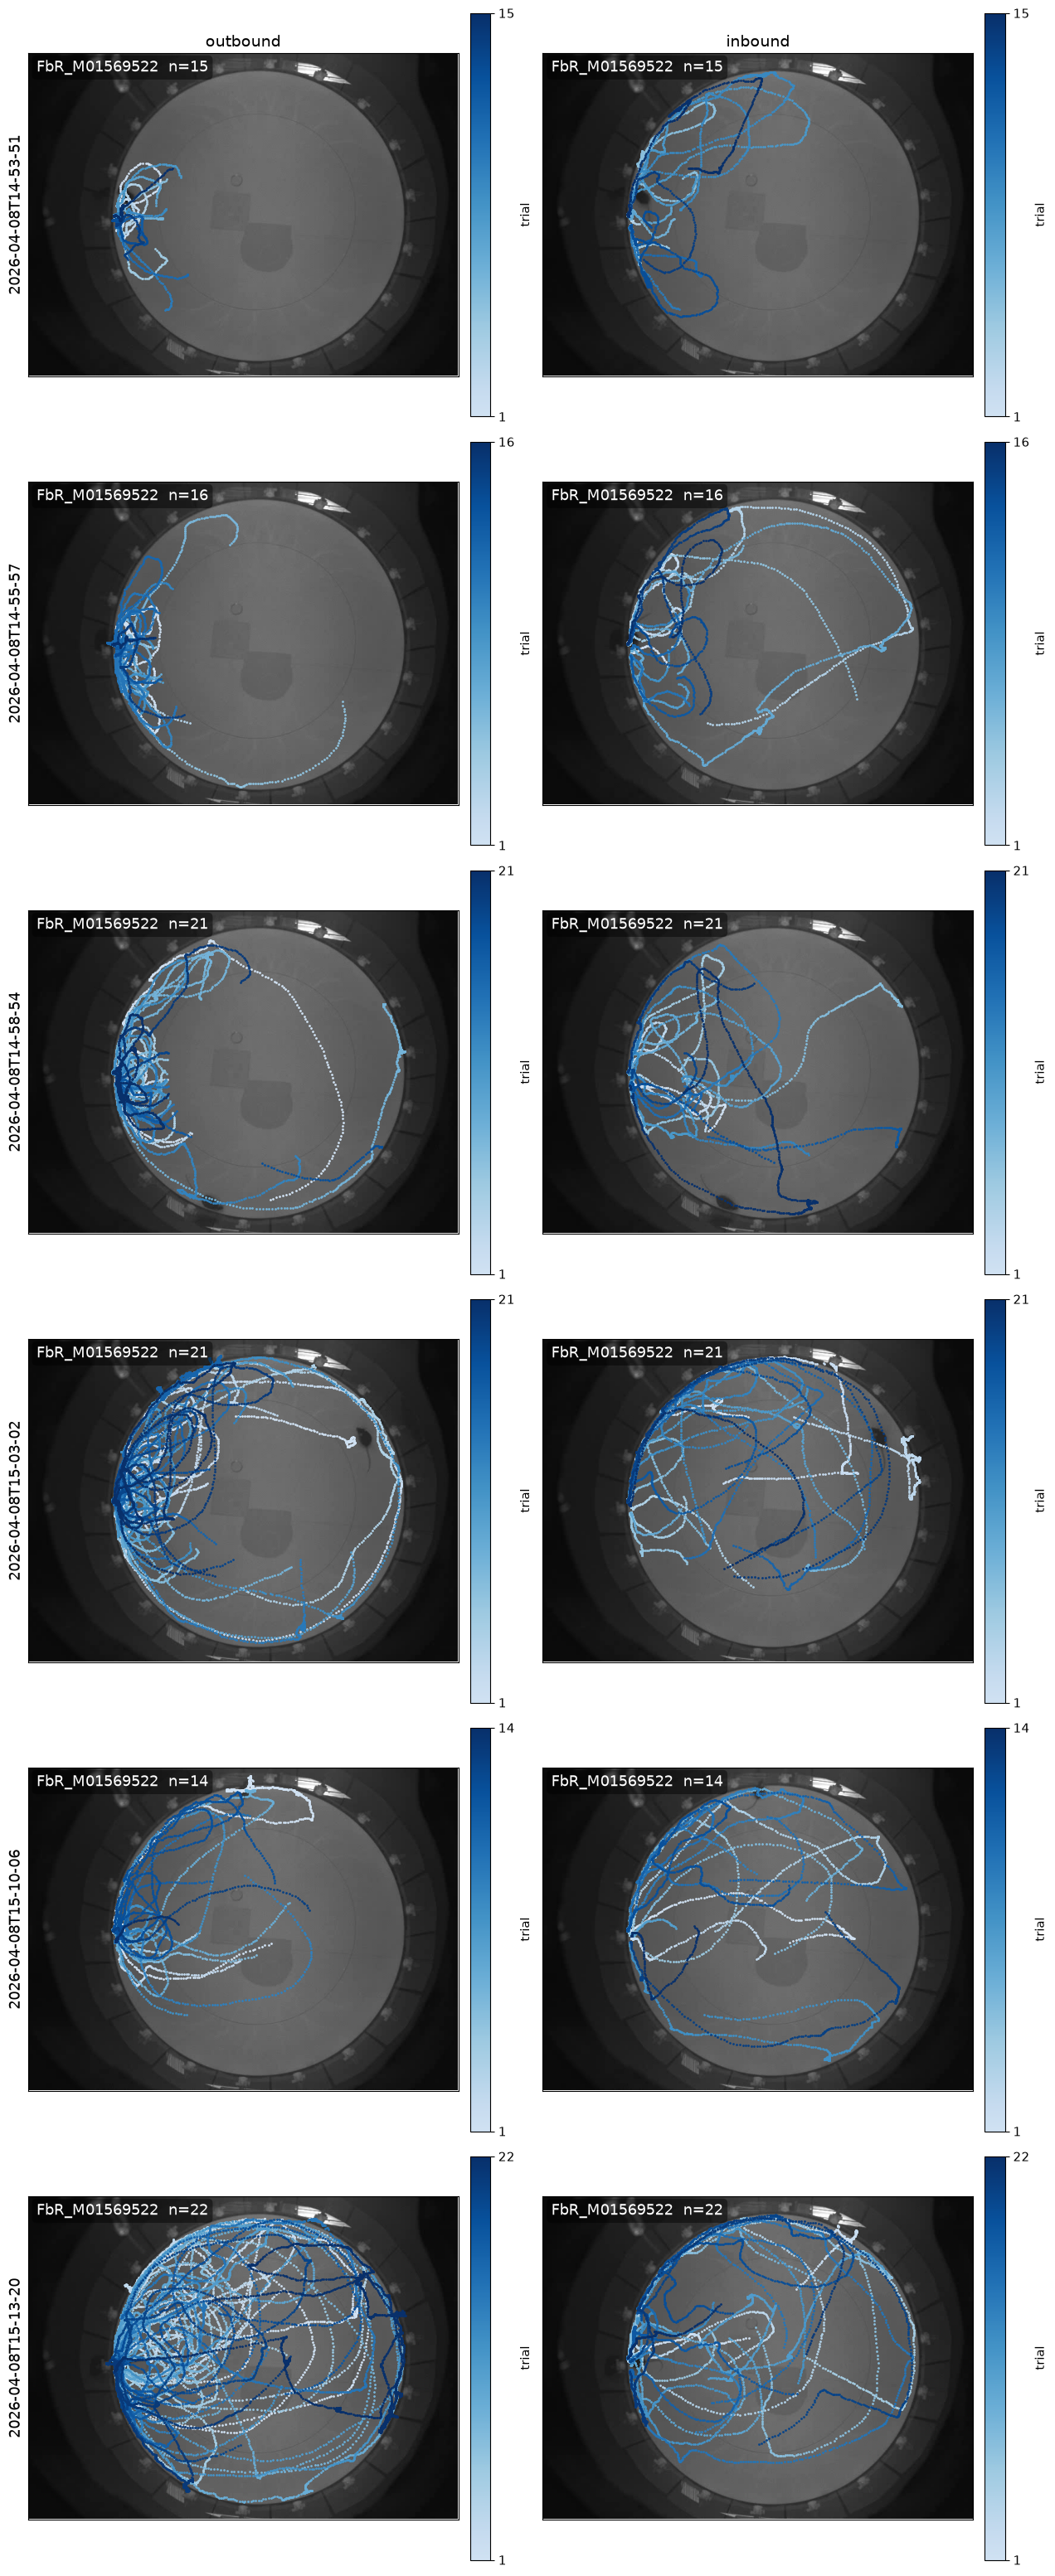

In [3]:
fig, axes = plot_path_grid(
    filtered_results, ROOT,
    mice=['FbR_M01569522'],
    row_by='session', col_by='segment',        # columns = outbound | inbound
    # centroid_points=('nose', 'body'),          # optional: subset for the centroid
)

### Plot 2 — all mice as columns, outbound + inbound each

Nest axes by passing a list: `col_by=['mouseID', 'segment']` gives one column block per mouse, each split into adjacent outbound | inbound. Rows are `day` (a day spans mice; `session` rows would be sparse since each session belongs to one mouse). Each mouse keeps its own colourmap, and the trial ramp spans the whole day.

To compare **groups** instead, pass `groups={'g1': {...}, 'g2': {...}}` and use `col_by=['group', 'segment']`; grouped plots colour by group by default.

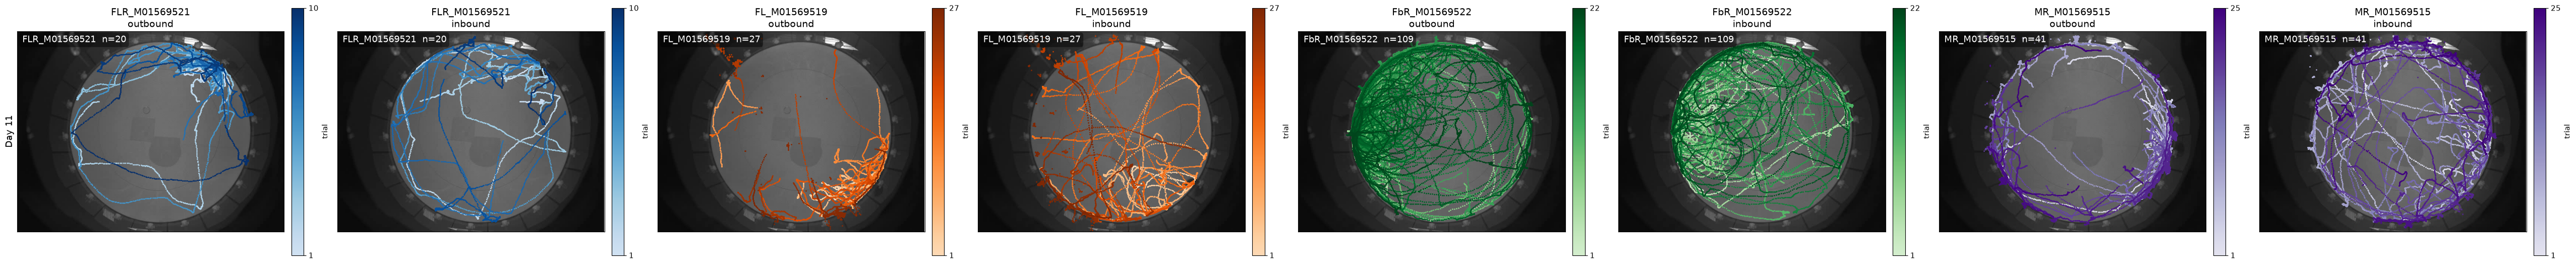

In [4]:
fig, axes = plot_path_grid(
    filtered_results, ROOT,
    row_by='day', col_by=['mouseID', 'segment'],   # columns = mouse x [outbound, inbound]
)

### Plot 3 — outbound & inbound split by outcome, per group

`outcome` (Success / Miss / Failure) is just another axis. Rows = outcome, columns = group × segment. Cells with no (valid) trials show the bare frame.

Traces are drawn with `movement`'s `plot_centroid_trajectory`. Each subpanel carries its active colour label (`group  n=…` here, or `mouseID  n=…` with `color_by='mouseID'`) and a slim trial colourbar (`colorbar=False` to drop them).

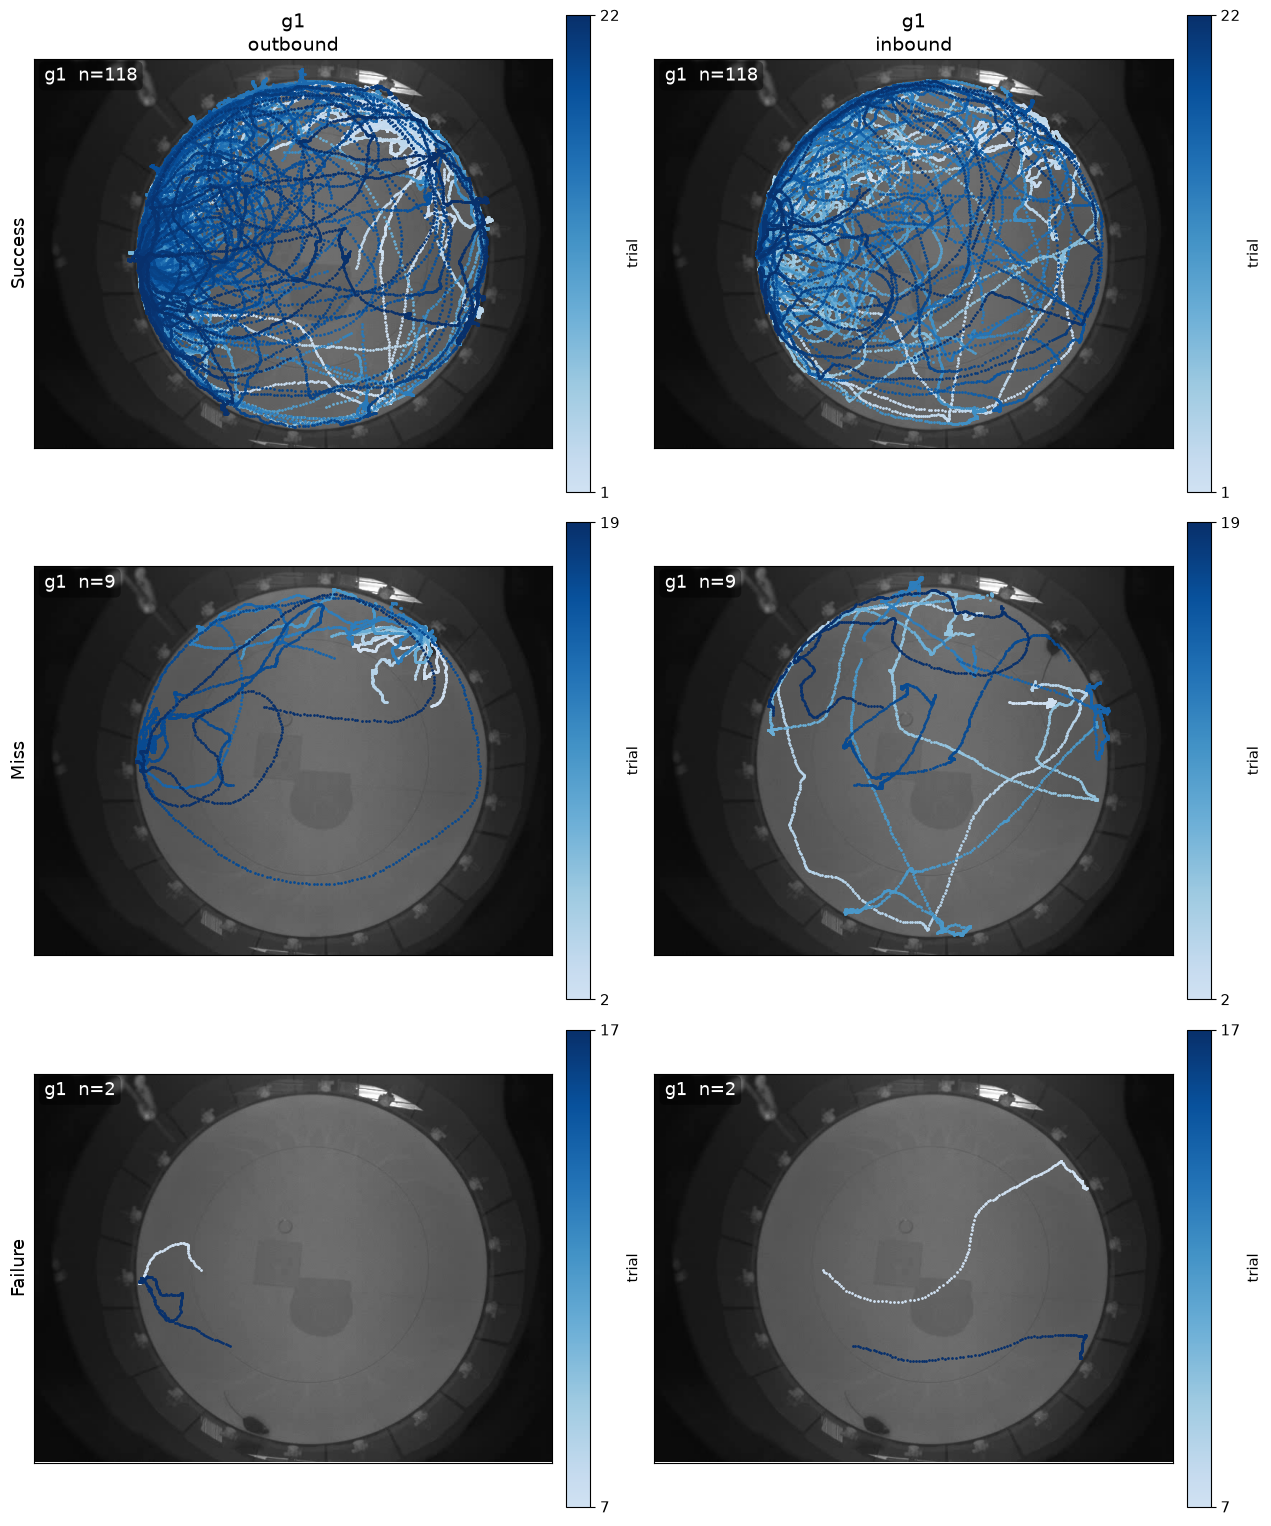

In [5]:
fig, axes = plot_path_grid(
    filtered_results, ROOT,
    groups={'g1': {'FbR_M01569522', 'FLR_M01569521'}},
    color_by='group',                  # explicit for clarity; this is now the default with groups=
    row_by='outcome',                    # Success / Miss / Failure
    col_by=['group', 'segment'],         # columns = group x [outbound, inbound]
)

### Plot 4 — one session, one outbound|inbound pair per trial

Pick one session from `available_sessions`, then use `trial_index` for rows and `segment` for columns so each trial gets an outbound panel beside its inbound panel.

Text(0.5, 1.01, 'Session 2026-04-08T13-46-57: outbound | inbound per trial')

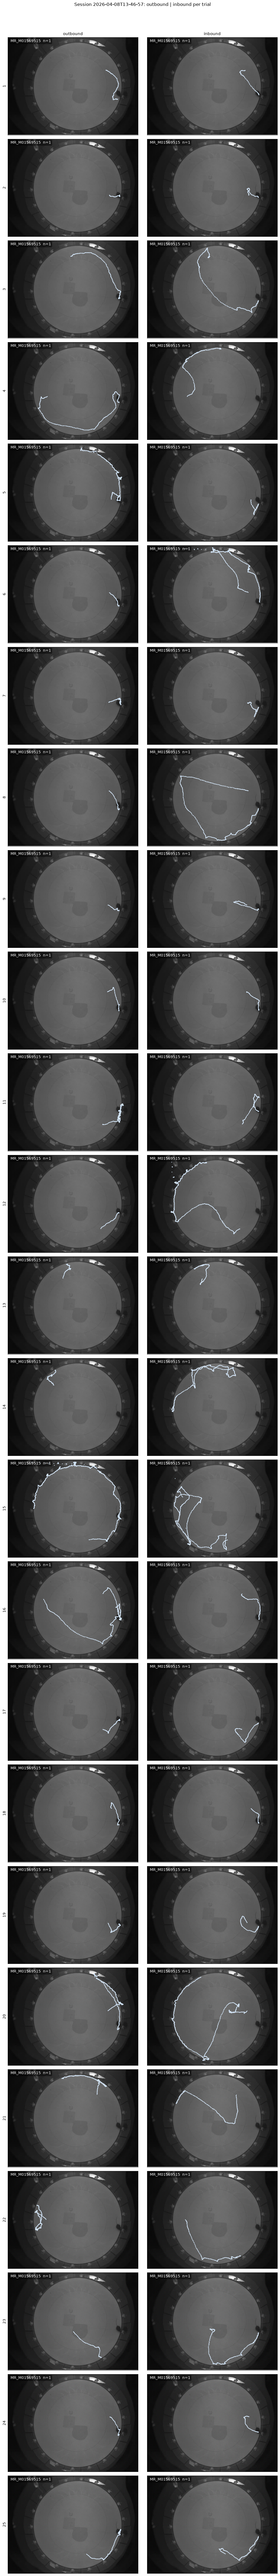

In [6]:
available_sessions = sorted(filtered_results['trials']['session'].unique())
session_id = available_sessions[0]  # change this to the session you want
session_results = filtered_results.copy()
session_results['trials'] = filtered_results['trials'].loc[
    filtered_results['trials']['session'].eq(session_id)
].copy()

fig, axes = plot_path_grid(
    session_results, ROOT,
    row_by='trial_index',               # one row per trial in this session
    col_by='segment',                   # outbound | inbound
    colorbar=False,                     # cleaner when there are many rows
    fontsize=10,
    figsize_per_cell=(5.6, 3.8),
)
fig.suptitle(f'Session {session_id}: outbound | inbound per trial', y=1.01)

In [7]:
from data_conduit.qc.slicing import slice_pose_for_trial

trials = filtered_results["trials"]
pose = filtered_results["dlc:position"]

sum(
    slice_pose_for_trial(pose, row, segment="inbound").sizes.get("Time", 0) > 0
    for _, row in trials.iterrows()
)

197